In [157]:
import json
import os

import agama
import gc_utils
import h5py
import matplotlib.pyplot as plt
import numpy as np
import utilities as ut
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from scipy.stats import gaussian_kde, norm

agama.setUnits(mass=1, length=1, velocity=1)
units = agama.getUnits()


# plt.rc("font", family="Nimbus Roman")
plt.rc("font", family="Nimbus Roman No9 L")

SMALL_SIZE = 10
MEDIUM_SIZE = 10
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title


Text(0, 0.5, 'E (10$^5$ km$^{2}$ s$^{-2}$)')

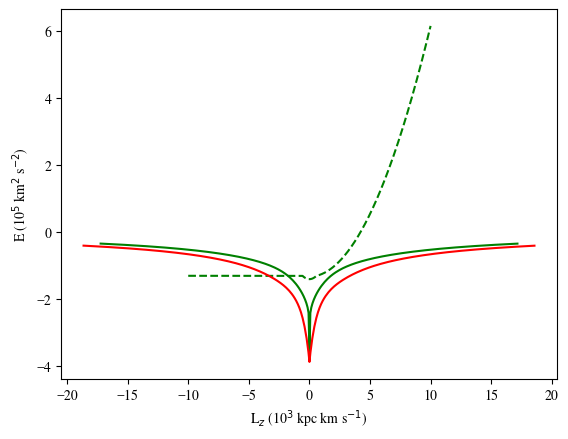

In [158]:
sim = "m12f"
sim_dir = "/Users/z5114326/Documents/simulations/"

snap = 600


pot_file = sim_dir + sim + "/potentials/snap_%d/combined_snap_%d.ini" % (snap, snap)
pot_fire = agama.Potential(pot_file)
af_fire = agama.ActionFinder(pot_fire, interp=False)

gala_fil = "../.venv312/lib/python3.12/site-packages/agama/data/PriceWhelan22.ini"
pot_gala = agama.Potential(gala_fil)
af_gala = agama.ActionFinder(pot_gala, interp=False)

lz_scale = 1e3
et_scale = 1e5

# Circular Orbits ################################################
r_c = np.arange(-100, 100, 0.5)
xyz_c = np.column_stack((r_c, r_c * 0, r_c * 0))

vcirc_gala = np.sqrt(-r_c * pot_gala.force(xyz_c)[:, 0])
vxyz_gala = np.column_stack((vcirc_gala * 0, vcirc_gala, vcirc_gala * 0))
posvel_gala = np.concatenate((xyz_c, vxyz_gala), axis=1)
lz_gala = af_gala(posvel_gala)[:, 2]
et_gala = 0.5 * np.sum(np.array(vxyz_gala) ** 2, axis=1) + pot_gala.potential(xyz_c)

vcirc_fire = np.sqrt(-r_c * pot_fire.force(xyz_c)[:, 0])
vxyz_fire = np.column_stack((vcirc_fire * 0, vcirc_fire, vcirc_fire * 0))
posvel_fire = np.concatenate((xyz_c, vxyz_fire), axis=1)
lz_fire = af_fire(posvel_fire)[:, 2]
et_fire = 0.5 * np.sum(np.array(vxyz_fire) ** 2, axis=1) + pot_fire.potential(xyz_c)

# Boundary ################################################
gala_lz_boundary = np.arange(-10, 10, 0.01)
gala_et_boundary = []
for lz_b in gala_lz_boundary:
    if lz_b < -0.58:
        gala_et_boundary.append(-1.316)
    elif lz_b < 0.58:
        gala_et_boundary.append(-1.416 + 0.3 * lz_b**2)
    else:
        gala_et_boundary.append(-1.341 + 0.075 * lz_b**2)
gala_lz_boundary = np.array(gala_lz_boundary) * lz_scale
gala_et_boundary = np.array(gala_et_boundary) * et_scale


# Rc_lim = pot_gala.Rcirc(E=-1.316 * et_scale)
# xyz_lim = np.column_stack((Rc_lim, np.zeros_like(Rc_lim), np.zeros_like(Rc_lim)))
# vcirc_lim = np.sqrt(-Rc_lim * pot_gala.force(xyz_lim)[:, 0])
# vxyz_lim = np.column_stack((vcirc_lim * 0, vcirc_lim, vcirc_lim * 0))
# posvel_lim = np.concatenate((xyz_lim, vxyz_lim), axis=1)
# lz_lim = af_gala(posvel_lim)[:, 2]

# lz_msk = -lz_lim <= gala_lz_boundary
# et_msk = gala_et_boundary < 0
# gala_lz_boundary = gala_lz_boundary[lz_msk & et_msk]
# gala_et_boundary = gala_et_boundary[lz_msk & et_msk]


plt.plot(lz_gala / lz_scale, et_gala / et_scale, c="green")
plt.plot(gala_lz_boundary / lz_scale, gala_et_boundary / et_scale, c="green", ls="--")

plt.plot(lz_fire / lz_scale, et_fire / et_scale, c="red")

plt.xlabel(r"L$_{z}$ (10$^3$ kpc km s$^{-1}$)")
plt.ylabel(r"E (10$^5$ km$^{2}$ s$^{-2}$)")

# plt.xlim(-1.6, 1.6)
# plt.ylim(-2.3, -0.7)


# Normalised Space

(-1.0, 0.0)

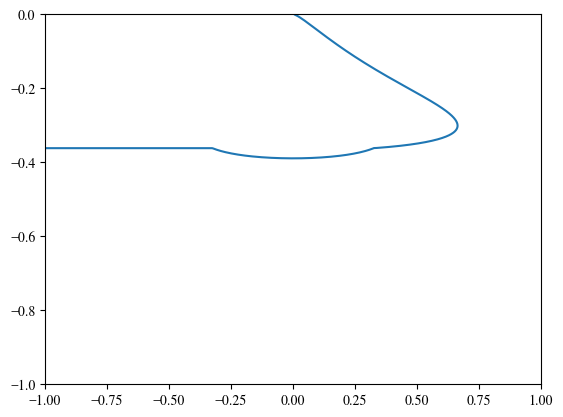

In [162]:
# Get circular orbit radius at same energy
Rc_gala_et = pot_gala.Rcirc(E=gala_et_boundary)
xyz_gala_et = np.column_stack((Rc_gala_et, np.zeros_like(Rc_gala_et), np.zeros_like(Rc_gala_et)))
vcirc_gala_et = np.sqrt(-Rc_gala_et * pot_gala.force(xyz_gala_et)[:, 0])
vxyz_gala_et = np.column_stack((vcirc_gala_et * 0, vcirc_gala_et, vcirc_gala_et * 0))
posvel_gala_et = np.concatenate((xyz_gala_et, vxyz_gala_et), axis=1)

lz_gala_et = af_gala(posvel_gala_et)[:, 2]

circ = gala_lz_boundary / lz_gala_et

E0_gala = pot_gala.potential([0, 0, 0])
et_norm = -(gala_et_boundary / E0_gala)

plt.plot(circ, et_norm)
plt.xlim(-1, 1)
plt.ylim(-1, 0)

Text(0, 0.5, 'E (10$^5$ km$^{2}$ s$^{-2}$)')

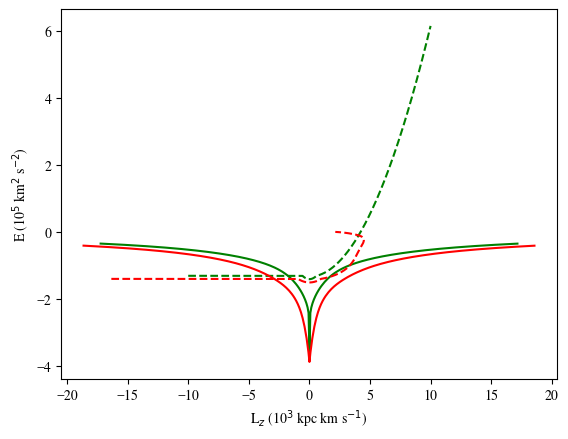

In [164]:
E0_fire = pot_fire.potential([0, 0, 0])
fire_et_boundary = -et_norm * E0_fire

Rc_fire_et = pot_fire.Rcirc(E=fire_et_boundary)
xyz_fire_et = np.column_stack((Rc_fire_et, np.zeros_like(Rc_fire_et), np.zeros_like(Rc_fire_et)))
vcirc_fire_et = np.sqrt(-Rc_fire_et * pot_fire.force(xyz_fire_et)[:, 0])
vxyz_fire_et = np.column_stack((vcirc_fire_et * 0, vcirc_fire_et, vcirc_fire_et * 0))
posvel_fire_et = np.concatenate((xyz_fire_et, vxyz_fire_et), axis=1)

lz_fire_et = af_fire(posvel_fire_et)[:, 2]

# circ = gala_lz_boundary / lz_gala_et
fire_lz_boundary = circ * lz_fire_et


plt.plot(lz_gala / lz_scale, et_gala / et_scale, c="green")
plt.plot(gala_lz_boundary / lz_scale, gala_et_boundary / et_scale, c="green", ls="--")

plt.plot(lz_fire / lz_scale, et_fire / et_scale, c="red")
plt.plot(fire_lz_boundary / lz_scale, fire_et_boundary / et_scale, c="red", ls="--")

plt.xlabel(r"L$_{z}$ (10$^3$ kpc km s$^{-1}$)")
plt.ylabel(r"E (10$^5$ km$^{2}$ s$^{-2}$)")

# plt.ylim(-4, -0.5)


(-1.0, 0.0)

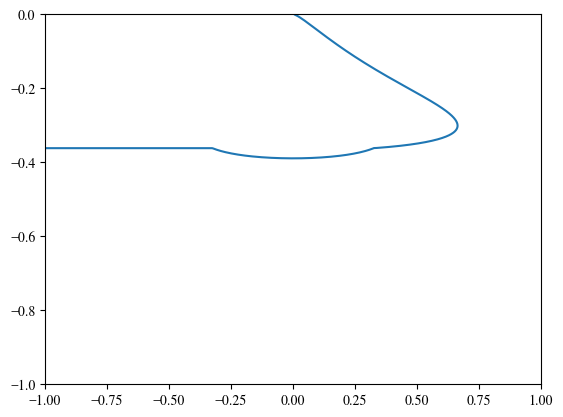

In [170]:
plt.plot(fire_lz_boundary / lz_fire_et, -fire_et_boundary / E0_fire)
plt.xlim(-1, 1)
plt.ylim(-1, 0)